In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    silhouette_score
)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("Country-data.csv")
print(df.head())
print(df.info())
print(df.isnull().sum())

               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-nul

In [3]:
countries = df['country']
df = df.drop('country', axis=1)

# EXPLORATORY DATA ANALYSIS


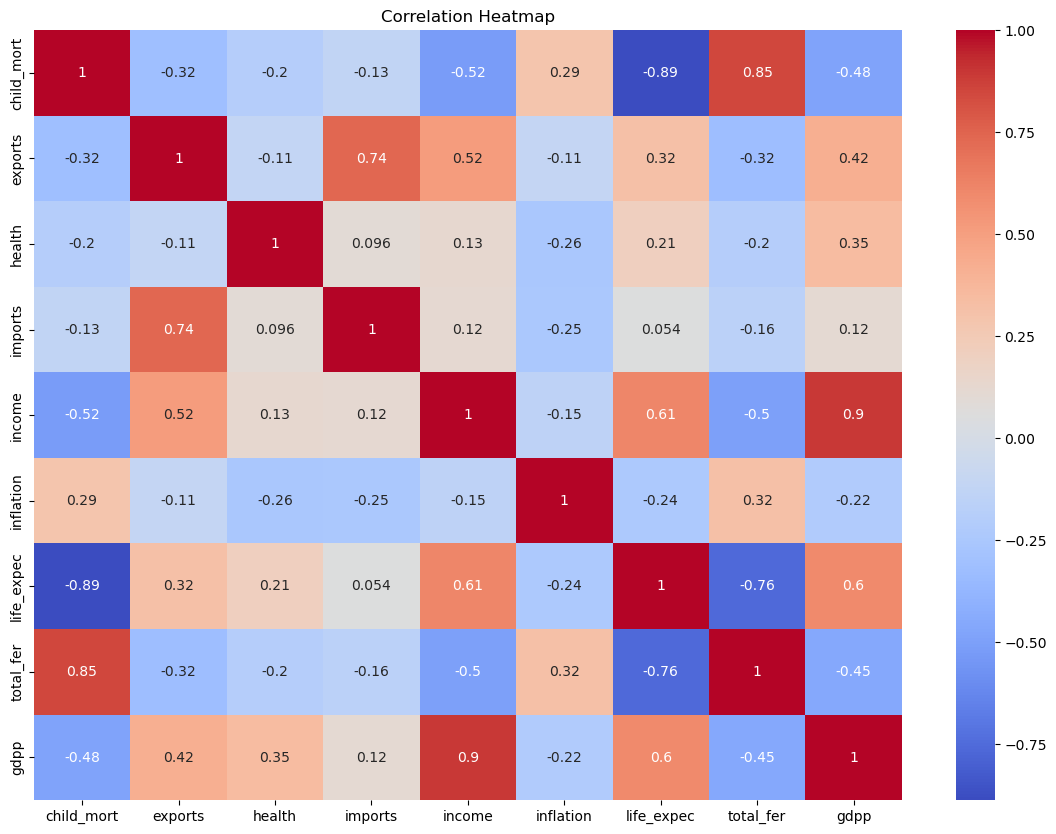

In [4]:
# Correlation Heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

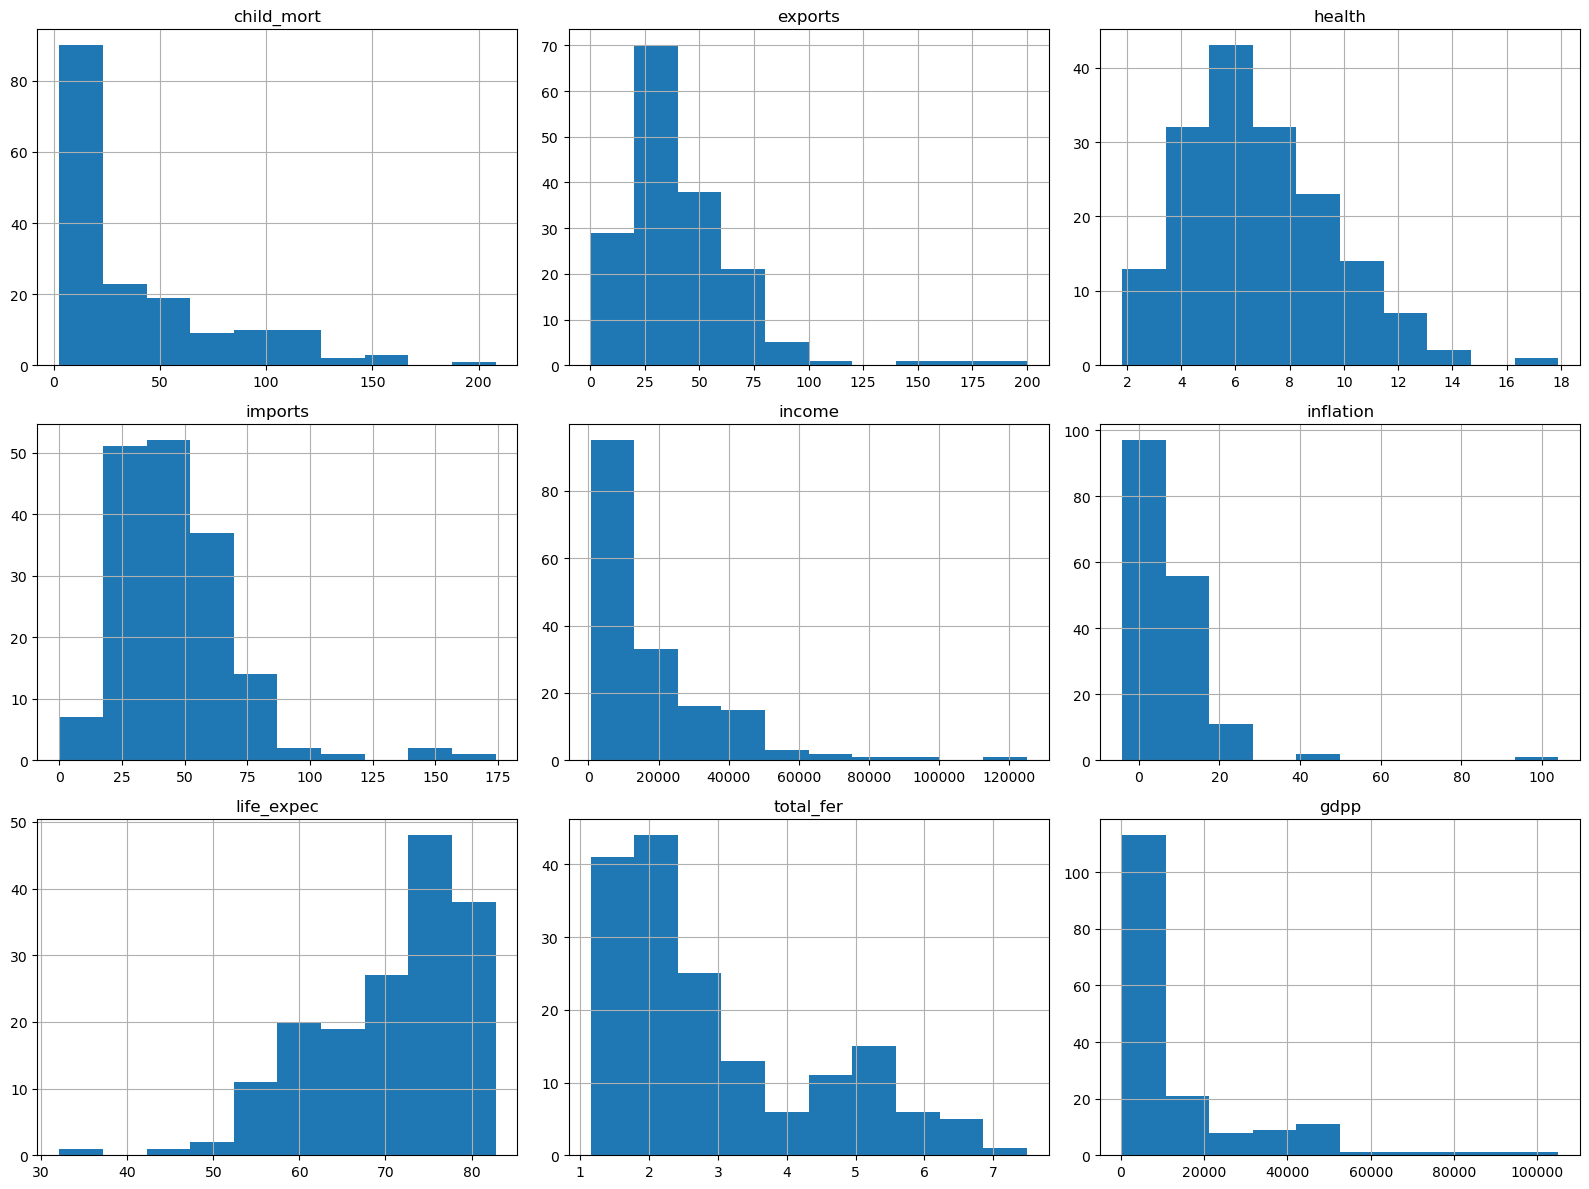

In [5]:
# Distribution plots
df.hist(figsize=(16,12))

plt.tight_layout()
plt.show()

# FEATURE SCALING


In [6]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=df.columns
)

print(scaled_df.head())

   child_mort   exports    health   imports    income  inflation  life_expec  \
0    1.291532 -1.138280  0.279088 -0.082455 -0.808245   0.157336   -1.619092   
1   -0.538949 -0.479658 -0.097016  0.070837 -0.375369  -0.312347    0.647866   
2   -0.272833 -0.099122 -0.966073 -0.641762 -0.220844   0.789274    0.670423   
3    2.007808  0.775381 -1.448071 -0.165315 -0.585043   1.387054   -1.179234   
4   -0.695634  0.160668 -0.286894  0.497568  0.101732  -0.601749    0.704258   

   total_fer      gdpp  
0   1.902882 -0.679180  
1  -0.859973 -0.485623  
2  -0.038404 -0.465376  
3   2.128151 -0.516268  
4  -0.541946 -0.041817  


# CREATE TARGET VARIABLE


In [8]:
median_income = df['income'].median()

df['target'] = df['income'].apply(
    lambda x: 1 if x > median_income else 0
)

print(df['target'].value_counts())

target
0    84
1    83
Name: count, dtype: int64


# TRAIN TEST SPLIT


In [9]:
X = scaled_df
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# RANDOM FOREST CLASSIFICATION


In [10]:
print("RANDOM FOREST CLASSIFICATION")

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print("\nRandom Forest Accuracy:")
print(rf_accuracy)

print("\nClassification Report:\n")
print(
    classification_report(
        y_test,
        rf_predictions
    )
)

RANDOM FOREST CLASSIFICATION

Random Forest Accuracy:
1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        16

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



# RANDOM FOREST CONFUSION MATRIX


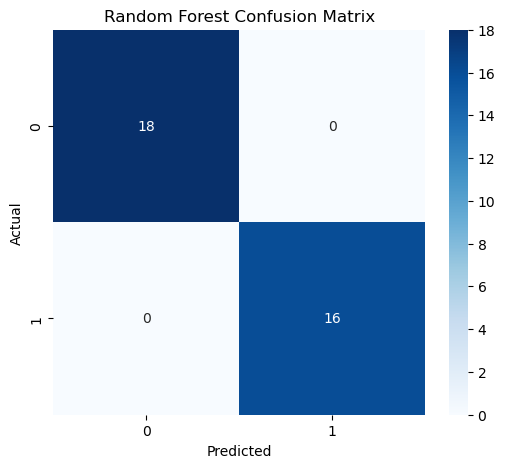

In [11]:
cm = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# XGBOOST CLASSIFICATION


In [12]:
print("XGBOOST CLASSIFICATION")

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(
    y_test,
    xgb_predictions
)

print("\nXGBoost Accuracy:")
print(xgb_accuracy)

print("\nClassification Report:\n")
print(
    classification_report(
        y_test,
        xgb_predictions
    )
)

XGBOOST CLASSIFICATION

XGBoost Accuracy:
1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        16

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



# FEATURE IMPORTANCE


      Feature  Importance
4      income    0.403716
8        gdpp    0.293245
0  child_mort    0.097016
6  life_expec    0.086766
7   total_fer    0.075489
5   inflation    0.018690
1     exports    0.017257
2      health    0.004424
3     imports    0.003397


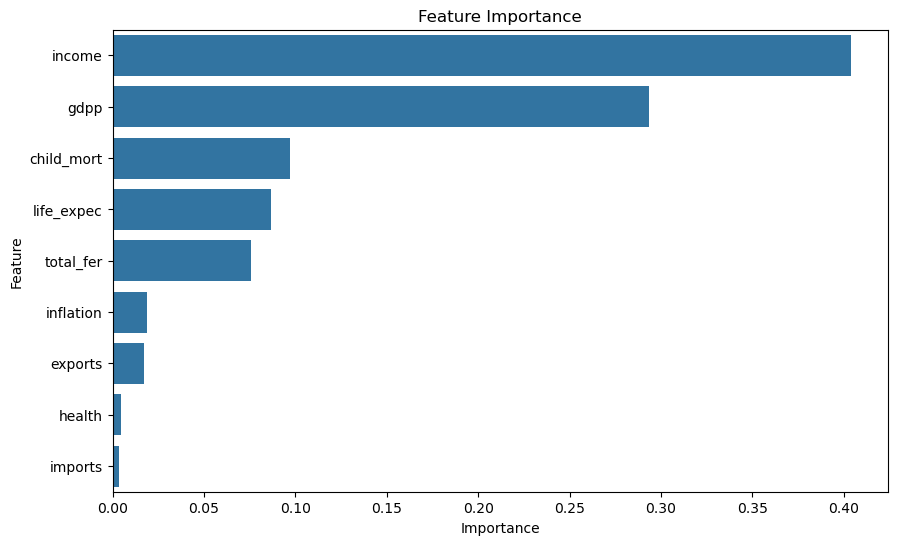

In [13]:
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

# Plot Feature Importance
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")
plt.show()

# K-MEANS CLUSTERING


K-MEANS CLUSTERING


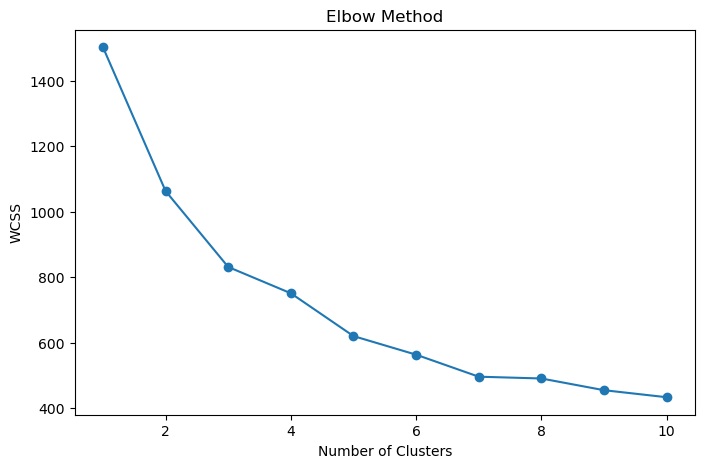


KMeans Cluster Counts:

KMeans_Cluster
0    86
2    45
1    36
Name: count, dtype: int64


In [14]:
print("K-MEANS CLUSTERING")

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(scaled_df)

    wcss.append(kmeans.inertia_)

# Elbow Curve
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

# Final KMeans Model
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

kmeans_labels = kmeans.fit_predict(
    scaled_df
)

df['KMeans_Cluster'] = kmeans_labels

print("\nKMeans Cluster Counts:\n")
print(df['KMeans_Cluster'].value_counts())

# PCA VISUALIZATION


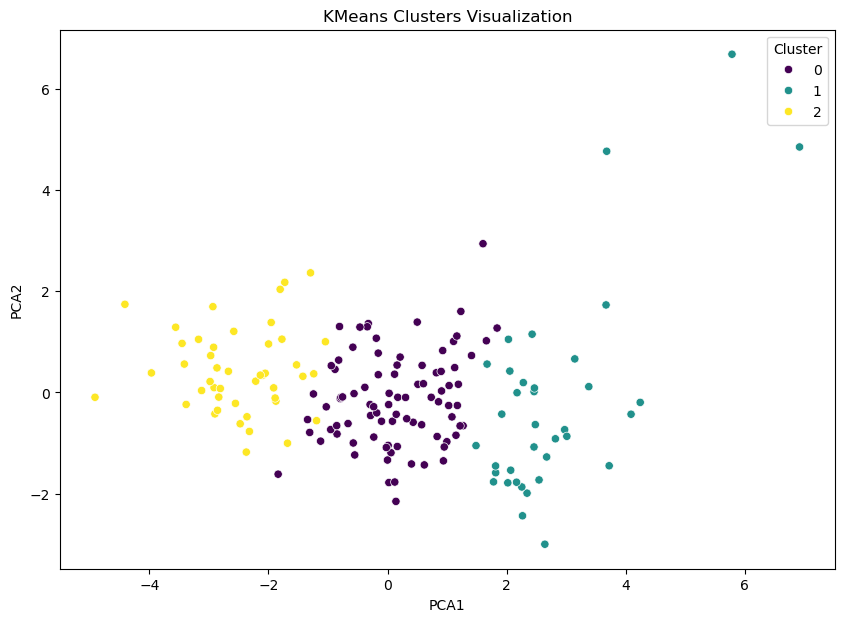

In [15]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(
    scaled_df
)

pca_df = pd.DataFrame(
    pca_data,
    columns=['PCA1', 'PCA2']
)

pca_df['Cluster'] = kmeans_labels

plt.figure(figsize=(10,7))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=pca_df,
    palette='viridis'
)

plt.title("KMeans Clusters Visualization")

plt.show()

# DBSCAN CLUSTERING


In [16]:
print("DBSCAN CLUSTERING")

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(
    scaled_df
)

df['DBSCAN_Cluster'] = dbscan_labels

print("\nDBSCAN Cluster Counts:\n")
print(df['DBSCAN_Cluster'].value_counts())

DBSCAN CLUSTERING

DBSCAN Cluster Counts:

DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64


# SILHOUETTE SCORE


In [17]:
kmeans_score = silhouette_score(
    scaled_df,
    kmeans_labels
)

print("\nKMeans Silhouette Score:")
print(kmeans_score)


KMeans Silhouette Score:
0.285600988953231


# CUSTOMER SEGMENTATION INSIGHTS


In [18]:
cluster_summary = df.groupby(
    'KMeans_Cluster'
).mean()

print("\nCLUSTER SUMMARY\n")
print(cluster_summary)


CLUSTER SUMMARY

                child_mort    exports    health    imports        income  \
KMeans_Cluster                                                             
0                22.456977  40.273128  6.251047  47.362394  12321.744186   
1                 5.000000  58.738889  8.807778  51.491667  45672.222222   
2                95.106667  28.602444  6.301111  42.306667   3539.844444   

                inflation  life_expec  total_fer          gdpp    target  \
KMeans_Cluster                                                             
0                7.720884   72.566279   2.340349   6461.767442  0.511628   
1                2.671250   80.127778   1.752778  42494.444444  1.000000   
2               11.986778   59.055556   5.065333   1766.711111  0.066667   

                DBSCAN_Cluster  
KMeans_Cluster                  
0                    -0.069767  
1                    -0.250000  
2                    -0.333333  


# SAVE FINAL OUTPUT


In [19]:
df.to_csv(
    "customer_intelligence_output.csv",
    index=False
)

print("PROJECT COMPLETED SUCCESSFULLY")
print("Output file saved:")
print("customer_intelligence_output.csv")

PROJECT COMPLETED SUCCESSFULLY
Output file saved:
customer_intelligence_output.csv
